In [1]:
import seaborn as sns 
from sklearn.datasets import make_blobs

In [4]:
X, y = make_blobs(
    n_samples= 1000,
    n_features = 2,
    centers = 4,
    random_state = 42
)

In [5]:
X

array([[-8.55503989,  7.06461794],
       [-6.13753182, -6.58081701],
       [-6.32130028, -6.8041042 ],
       ...,
       [ 3.69047995,  4.60555175],
       [-7.48913939, -7.0670809 ],
       [-9.40049578,  7.11430104]], shape=(1000, 2))

In [6]:
y

array([3, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 3, 0, 2, 2, 2, 0, 0, 0, 1, 1, 3,
       3, 3, 1, 1, 0, 0, 2, 1, 2, 2, 2, 0, 0, 3, 2, 1, 3, 3, 1, 2, 1, 3,
       1, 3, 0, 1, 3, 1, 2, 0, 1, 3, 0, 3, 0, 0, 0, 2, 2, 0, 2, 3, 1, 0,
       2, 2, 1, 0, 3, 0, 1, 2, 1, 3, 1, 0, 1, 0, 2, 0, 0, 0, 1, 3, 2, 2,
       0, 0, 0, 0, 1, 1, 3, 1, 3, 0, 1, 2, 1, 3, 3, 0, 3, 1, 1, 0, 2, 0,
       3, 2, 1, 1, 1, 1, 2, 3, 2, 1, 0, 2, 3, 1, 3, 2, 1, 3, 2, 1, 0, 2,
       1, 3, 1, 3, 0, 2, 1, 1, 0, 0, 3, 3, 3, 1, 1, 0, 0, 0, 0, 3, 2, 2,
       0, 1, 0, 1, 1, 3, 2, 0, 1, 2, 0, 0, 1, 2, 3, 2, 1, 0, 0, 1, 0, 3,
       2, 3, 2, 3, 1, 1, 0, 2, 0, 2, 1, 3, 0, 2, 1, 0, 1, 1, 0, 3, 2, 2,
       2, 3, 0, 2, 1, 0, 1, 1, 2, 0, 1, 2, 2, 3, 2, 2, 1, 0, 2, 0, 3, 1,
       3, 3, 2, 0, 3, 0, 1, 2, 2, 0, 0, 2, 0, 3, 2, 2, 3, 2, 2, 1, 2, 3,
       2, 1, 3, 0, 1, 0, 1, 1, 1, 1, 3, 1, 1, 2, 0, 2, 2, 1, 1, 1, 3, 1,
       3, 3, 2, 1, 0, 3, 1, 0, 1, 2, 0, 3, 1, 3, 2, 1, 3, 2, 3, 1, 2, 0,
       0, 2, 0, 3, 3, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2,

<Axes: >

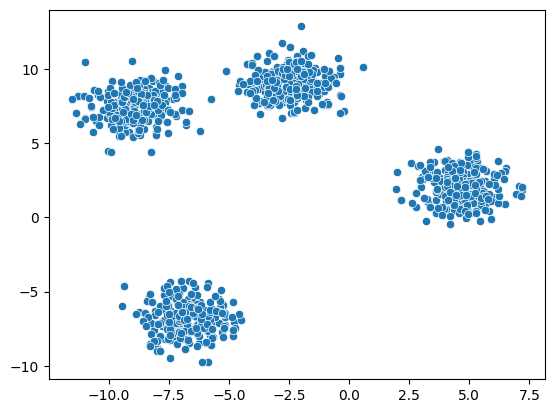

In [8]:
sns.scatterplot(x=X[:,0], y=X[:,1])

In [9]:
from sklearn.cluster import KMeans

In [14]:
K = 4

kmeans = KMeans(
    n_clusters= K,
    random_state=42
)

In [15]:
labels = kmeans.fit_predict(X)

<Axes: >

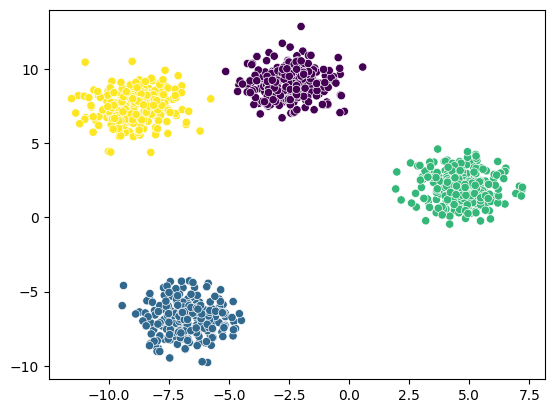

In [16]:
sns.scatterplot(x=X[:,0], y=X[:,1], c=labels)

### Choose our k value - Elbow, Silhouette Score

In [17]:
wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

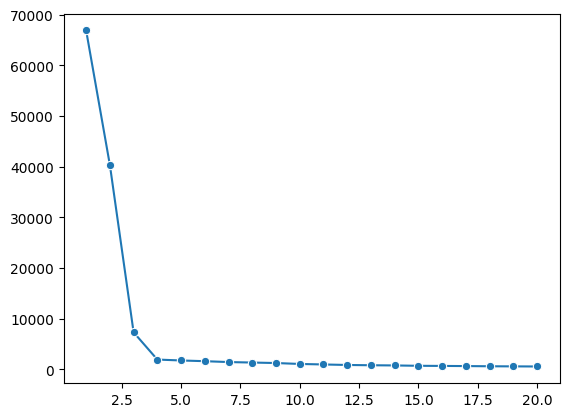

In [20]:
sns.lineplot(x=range(1, 21), y=wcss, marker="o")

In [23]:
from kneed import KneeLocator

In [24]:
knee =KneeLocator(range(1, 21), wcss, curve= "convex", direction="decreasing")

In [25]:
print(knee.elbow)

4


### Silhouette score

In [27]:
from sklearn.metrics import silhouette_score

In [31]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    ss.append(score)

<Axes: >

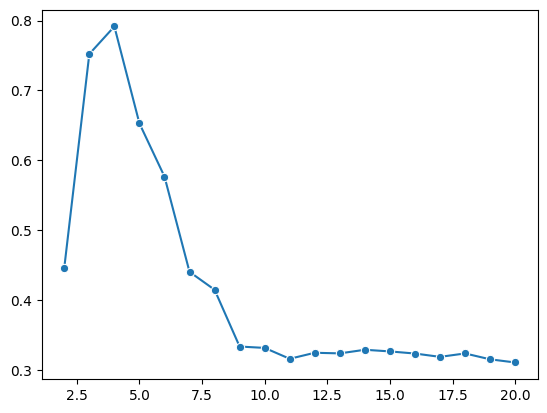

In [33]:
sns.lineplot(x=range(2,21), y=ss, marker="o")